# CNN 101 — Convolutional Neural Network Fundamentals

This notebook demonstrates the two core operations that underpin every CNN layer:

1. **Convolution** — a small filter (kernel) slides over the image, computing a weighted sum of neighbouring pixels to detect features such as edges.
2. **Max Pooling** — the feature map is divided into 2×2 blocks and only the maximum value in each block is kept, halving the spatial dimensions while retaining the strongest features.

In [2]:
# see
#

## 1. Import Libraries & Load Image

- `cv2` (OpenCV) — image processing utilities  
- `numpy` — array operations  
- `skimage.data.camera()` — a built-in 512×512 grayscale test image (photograph of a cameraman)

In [1]:
import cv2
import numpy as np  
from skimage import data
i = data.camera()

## 2. Display the Original Image

Render the raw grayscale image before any processing so we have a visual baseline to compare against the filtered result.

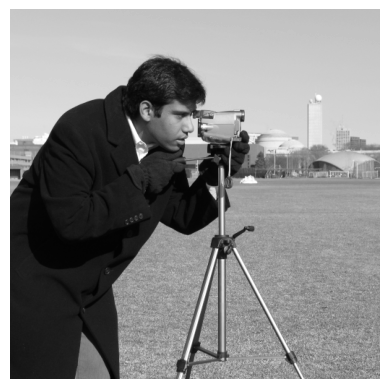

In [2]:
import matplotlib.pyplot as plt
plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(i)
plt.show()

## 3. Prepare the Output Array

Create a copy of the image to write filtered values into (so the original pixel values remain available for look-ups during convolution), and store the image dimensions.

In [3]:
i_transformed = np.copy(i)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

## 4. Define a Convolution Filter (Kernel)

A **3×3 convolution filter** is a matrix of weights that determines which features the layer responds to.  
The filter slides over each pixel, computes the dot product with the local 3×3 neighbourhood, and writes a single output value.

| Filter | Effect |
|---|---|
| `[[-1,-2,-1],[0,0,0],[1,2,1]]` | **Sobel Y** — highlights horizontal edges |
| `[[-1,0,1],[-2,0,2],[-1,0,1]]` | **Sobel X** — highlights vertical edges |
| `[[0,1,0],[1,-4,1],[0,1,0]]` | **Laplacian** — highlights all edges |

`weight` is a normalisation factor applied after summing (useful when filter weights don't sum to 0 or 1).

In [4]:
# This filter detects edges nicely
# It creates a filter that only passes through sharp edges and straight lines. 
# Experiment with different values for fun effects.
#filter = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]] 
# A couple more filters to try for fun!
filter = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
#filter = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
 # If all the digits in the filter don't add up to 0 or 1, you 
# should probably do a weight to get it to do so
# so, for example, if your weights are 1,1,1 1,2,1 1,1,1
# They add up to 10, so you would set a weight of .1 if you want to normalize them
weight  = 1

## 5. Apply the Convolution

Iterate over every interior pixel (skipping the 1-pixel border, since a 3×3 kernel centred on a border pixel would reach outside the image).  
For each pixel, multiply its 3×3 neighbourhood element-wise with the filter and sum the results.  
Clamp the result to **[0, 255]** to keep it a valid 8-bit pixel value.

In [ ]:
for x in range(1, size_x - 1):       # skip left/right border columns
  for y in range(1, size_y - 1):     # skip top/bottom border rows
      output_pixel = 0.0
      # --- Top row of the 3×3 neighbourhood ---
      output_pixel += i[x - 1, y - 1] * filter[0][0]   # top-left
      output_pixel += i[x,     y - 1] * filter[0][1]   # top-centre
      output_pixel += i[x + 1, y - 1] * filter[0][2]   # top-right
      # --- Middle row ---
      output_pixel += i[x - 1, y    ] * filter[1][0]   # mid-left
      output_pixel += i[x,     y    ] * filter[1][1]   # centre (current pixel)
      output_pixel += i[x + 1, y    ] * filter[1][2]   # mid-right
      # --- Bottom row ---
      output_pixel += i[x - 1, y + 1] * filter[2][0]   # bot-left
      output_pixel += i[x,     y + 1] * filter[2][1]   # bot-centre
      output_pixel += i[x + 1, y + 1] * filter[2][2]   # bot-right
      output_pixel *= weight           # apply normalisation factor
      # Clamp to valid 8-bit pixel range [0, 255]
      if output_pixel < 0:
          output_pixel = 0
      if output_pixel > 255:
          output_pixel = 255
      i_transformed[x, y] = output_pixel

## 6. Display the Filtered Image

The axes still show 512×512 — convolution preserves spatial dimensions.  
Edge regions appear bright where the filter detected strong gradients; flat areas become dark.

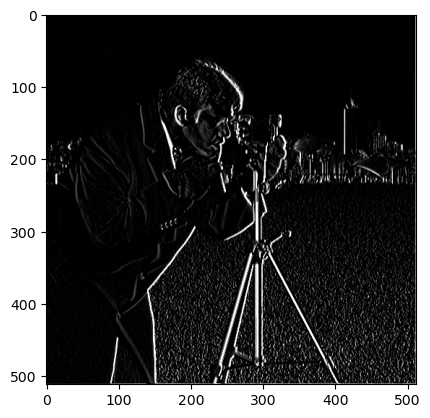

In [6]:
# Plot the image. Note the size of the axes -- they are 512 by 512
plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
#plt.axis('off')
plt.show()   

## 7. Max Pooling (2×2, stride 2)

**Max pooling** downsamples the feature map by:
1. Dividing the image into non-overlapping **2×2 blocks** (stride = 2)
2. Taking the **maximum** pixel value from each block

Result: a 256×256 image — the same detected edges, but half the resolution.  
Benefits in a CNN:
- Reduces the number of parameters for subsequent layers
- Provides a degree of **translation invariance** (small shifts in input don't change the output much)

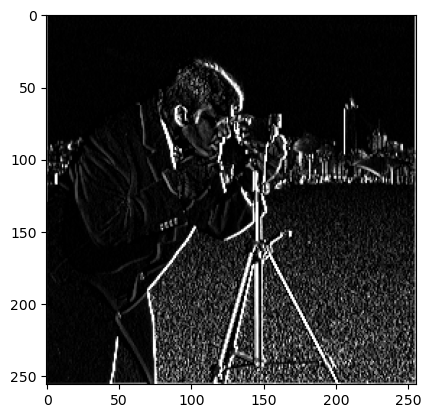

In [ ]:
new_x = int(size_x / 2)          # output height: 256
new_y = int(size_y / 2)          # output width:  256
newImage = np.zeros((new_x, new_y))

for x in range(0, size_x, 2):   # step by 2 — one 2×2 block per iteration
  for y in range(0, size_y, 2):
    # Collect the 4 pixels in the current 2×2 block
    pixels = []
    pixels.append(i_transformed[x,     y    ])   # top-left
    pixels.append(i_transformed[x + 1, y    ])   # top-right
    pixels.append(i_transformed[x,     y + 1])   # bottom-left
    pixels.append(i_transformed[x + 1, y + 1])   # bottom-right
    pixels.sort(reverse=True)    # sort descending
    newImage[int(x / 2), int(y / 2)] = pixels[0] # keep the maximum value

# Plot the result — axes now show 256×256 instead of 512×512
plt.gray()
plt.grid(False)
plt.imshow(newImage)
#plt.axis('off')
plt.show()